<a href="https://colab.research.google.com/github/801-Hillside-Terrace/SMART-2026/blob/main/week1/Week1_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Topics: Coding Review, Modeling Paradigm, Regression Intro

In [63]:
#imports
import math
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import csv

#load data
url = 'https://raw.githubusercontent.com/801-Hillside-Terrace/SMART-2026/main/week1/Concrete_Data%20-%20Sheet1.csv'
concrete_data = pd.read_csv(url)
concrete_data.columns


Index(['Cement (component 1)(kg in a m^3 mixture)',
       'Blast Furnace Slag (component 2)(kg in a m^3 mixture)',
       'Fly Ash (component 3)(kg in a m^3 mixture)',
       'Water  (component 4)(kg in a m^3 mixture)',
       'Superplasticizer (component 5)(kg in a m^3 mixture)',
       'Coarse Aggregate  (component 6)(kg in a m^3 mixture)',
       'Fine Aggregate (component 7)(kg in a m^3 mixture)', 'Age (day)',
       'Concrete compressive strength(MPa, megapascals) '],
      dtype='object')

In [64]:
#some common/useful data frame checks:

#concrete_data.head() # see the first 5 rows
#concrete_data.columns # get column names
#concrete_data.shape # get dimensions (rows x columns)
#concrete_data.describe() # get summary statistics
#concrete_data.dtypes # get data type for each column
#concrete_data.isnull().sum() # count number of missing values

#some basic data slicing and manipulation etc:

#selecting columns by name, renaming them, dropping them:
concrete_data['Concrete compressive strength(MPa, megapascals) '] # select named column
concrete_data.rename(columns = {'Concrete compressive strength(MPa, megapascals) ': 'Target'}, inplace = True) # rename named column to Target
concrete_data[['Blast Furnace Slag (component 2)(kg in a m^3 mixture)', 'Fly Ash (component 3)(kg in a m^3 mixture)']] # select multiple columns by name
concrete_data[concrete_data.columns.to_numpy()[4]] # select fifth column (indexing starts at 0 not 1, so index 4 is the location of the fifth column)
concrete_data[concrete_data.columns.to_numpy()[2:4]] # select third and fourth column (2:4 goes from 2 to 3)
y = concrete_data['Target'] # select just Target column and call it Y
X = concrete_data.drop(columns = ['Target']) # drop Target column, keep the rest, and call it X

#row selection:
X.iloc[0:3] # select first 3 rows of X (row 0, row 1, row 2)
X.iloc[10:20] # select 11th to 20th row (index 10 to index 19)
X.iloc[[0,3,7]] # select 1st, 4th, and 8th row (index 0, index 3, index 7)
X.iloc[-1] # select the last row
X.iloc[-2:] # select the last two rows
X.iloc[:-1] # select all but the last row
X.iloc[::-1] # select all rows but in reversed order
X.iloc[::2] # selects every second row (index 0, index 2, index 4,...)
X[X['Age (day)'] > 3] # selects every row where Age is over 3

#indexing:
X.iloc[0,0] # select first row of the first column
X.iloc[:, 0] # select the entire first column
X.iloc[:, 0:2] # select the entire first two columns
X.iloc[1:3, :4] # select the second and third row of the first 4 columns

#creating new columns/variables/calculations:
X['Water Squared'] = X['Water  (component 4)(kg in a m^3 mixture)'] ** 2 # ( ** n raises to nth power)
X['Cement/Water Ratio'] = X['Cement (component 1)(kg in a m^3 mixture)'] / X['Water  (component 4)(kg in a m^3 mixture)']
X['Log Cement'] = np.log(X['Cement (component 1)(kg in a m^3 mixture)']) # numpy has a lot of common functions (np.exp(), np.sqrt() etc.)
X['Log Cement'].mean() # get mean value of Log Cement column
X['Log Cement'].var() # get variance of Log Cement column
X['Log Cement'].var(ddof = 1) # get sample variance of Log Cement column

#converting from dataframes/series to numpy arrays (more like vectors/matrices):
X_m = X.to_numpy() # converts to numpy array
y_m = y.to_numpy()



In [65]:
url = 'https://raw.githubusercontent.com/801-Hillside-Terrace/SMART-2026/main/week1/Concrete_Data%20-%20Sheet1.csv'
concrete_data = pd.read_csv(url)

# Quick Practice:

# Use concrete_data from above
# 1. What is the second column named?
#ans1 = # fill in here
#print(ans1)
# 2. What is the column at index 4 named?
#ans2 = # fill in here
#print(ans2)
# 3. How many rows are there?
#ans3 = # fill in here
#print(ans3)
# 4. After filtering to only concrete over 100 days old, what is the value of the last observation for compressive strength?
#ans4 = # fill in here
#print(ans4)


In [66]:
#vectors and matrices:

print('y_m Shape: ',y_m.shape) # vector (1D array) dimension (n,)
print('X_m Shape: ', X_m.shape) # matrix (2D array) dimension (n,p)

#indexing is similar to iloc method:
X_m[:,0] # all rows, first column
print('X_m[:,0] Shape: ', X_m[:,0].shape) # dimension (n,)

#operations:
X_m.T # transpose
print('X_m.T Shape: ', X_m.T.shape) # dimensions flip
y_m @ X_m # multiplication uses @
print('(y_m @ X_m) Shape: ', (y_m @ X_m).shape) # dimension (p,)
np.dot(y_m, y_m) # dot product
print('np.dot(y_m, y_m) Shape: ',np.dot(y_m, y_m).shape) # scalar
np.eye(3) # creates 3x3 identity matrix
print('3x3 Identity Matrix: ','\n', np.eye(3))
np.zeros(3) # creates vector of 3 zeroes
np.ones(3) # creates vector of 3 ones
np.c_[np.zeros(3), np.ones(3)] # concatenate columns
np.linalg.inv(X_m.T @ X_m) # matrix inverse
np.allclose(np.linalg.inv(X_m.T @ X_m) @ (X_m.T @ X_m), np.eye(X_m.shape[1])) # showing inverse times matrix gives identity


y_m Shape:  (1030,)
X_m Shape:  (1030, 11)
X_m[:,0] Shape:  (1030,)
X_m.T Shape:  (11, 1030)
(y_m @ X_m) Shape:  (11,)
np.dot(y_m, y_m) Shape:  ()
3x3 Identity Matrix:  
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


True

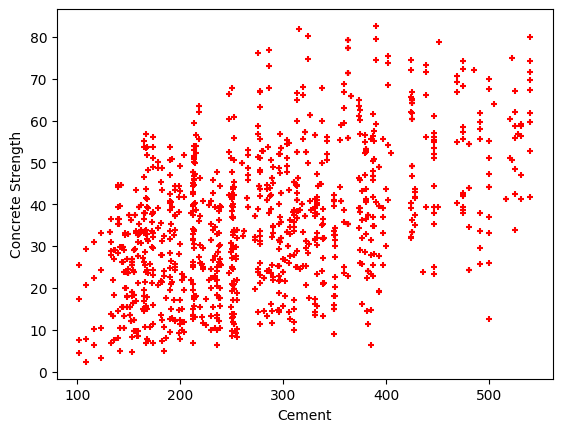

<Axes: >

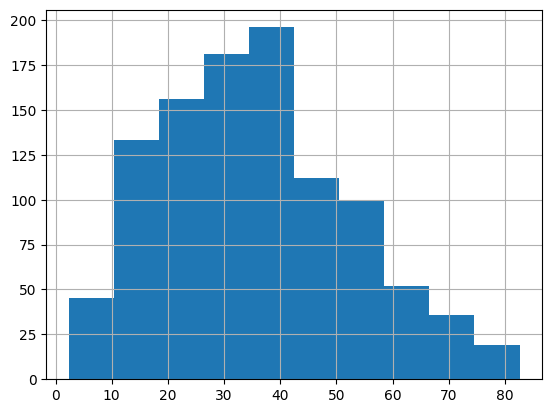

In [67]:
#basic plotting:

#scatterplot
plt.scatter(X.iloc[:,0], y, color = 'red', marker = '+', s = 17) # (x,y, color, marker shape, size)
plt.xlabel('Cement')
plt.ylabel('Concrete Strength')
plt.show()

#histogram of Y
y.hist()

In [68]:
#basic functions:
def square_root(x):
  return x ** (1/2)
print(square_root(49))

def multiply(x,y):
  return x * y
print(multiply(3,5))

7.0
15


Every machine learning problem involves the following 4 components:
1. The data to be used/learned from.
2. A model to transform the data in a way useful for solving the problem (usually predicting the target).  A model is ultimately a function of the data that has learnable parameters.
3. An objective function (often called a loss function) which quantifies how well the model is performing.
4. An algorithm that adjusts the model's parameters to optimize the objective function.

Linear regression is the simplest and most popular model for regression problems ("regression" in the ML context referring to when the target is a numerical value rather than a class etc).  The main assumption is that the conditional mean of the target/dependent variable $Y$ given the features/covariates/independent variables $X$ is approximately linear.  More explicitly, that $E[Y|X=x]$ can be expressed as a weighted sum of the features.  For inference (especially with smaller samples) another important assumption is Normality of the errors.  

Our 4 components are then:
1. The data, where $y\in\mathbb{R}^n$ is the $n$ observations of the target variable and $X\in \mathbb{R}^{n\times (p+1)}$ is the $n$ observations of the $p$ features with the first column being all 1s for fitting the intercept.
2. The model: $\hat{y}=X\beta$ where $\beta\in\mathbb{R}^{(p+1)\times 1}$.
3. The typical objective function is mean squared error (MSE): $\frac{1}{n}||y-X\beta||^2$.
4. When using MSE as our objective function we have an analytic solution (closed form) obtained from some calculus:
$$ \hat{\beta}=(X^TX)^{-1}X^Ty$$

Fitting linear regression manually for practice:


In [69]:
url = 'https://raw.githubusercontent.com/801-Hillside-Terrace/SMART-2026/main/week1/Concrete_Data%20-%20Sheet1.csv'
concrete_data = pd.read_csv(url)
concrete_data.columns

Index(['Cement (component 1)(kg in a m^3 mixture)',
       'Blast Furnace Slag (component 2)(kg in a m^3 mixture)',
       'Fly Ash (component 3)(kg in a m^3 mixture)',
       'Water  (component 4)(kg in a m^3 mixture)',
       'Superplasticizer (component 5)(kg in a m^3 mixture)',
       'Coarse Aggregate  (component 6)(kg in a m^3 mixture)',
       'Fine Aggregate (component 7)(kg in a m^3 mixture)', 'Age (day)',
       'Concrete compressive strength(MPa, megapascals) '],
      dtype='object')

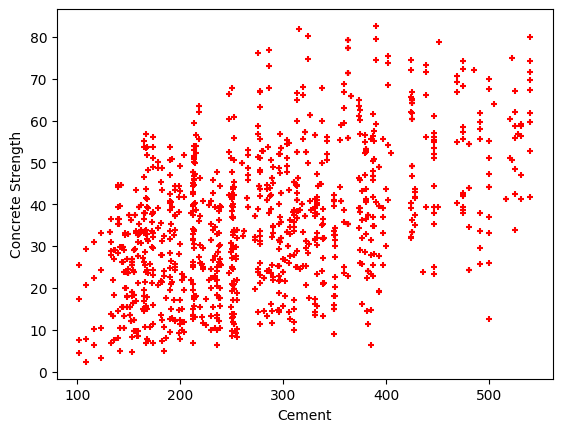

np.float64(209.71131982955583)

In [70]:
# target compressive strength, feature cement
X = concrete_data['Cement (component 1)(kg in a m^3 mixture)']
y = concrete_data['Concrete compressive strength(MPa, megapascals) ']

# check the plot
plt.scatter(X, y, color = 'red', marker = '+', s = 17)
plt.xlabel('Cement')
plt.ylabel('Concrete Strength')
plt.show()

# create matrices
X_m = np.c_[np.ones(X.shape[0]), X.to_numpy()] # don't forget the intercept
y_m = y.to_numpy()
beta_hat = np.linalg.inv(X_m.T @ X_m) @ X_m.T @ y_m # get beta hat using equation
y_predicted = X_m @ beta_hat # get predicted y values

# compute MSE
def MSE(y, y_predicted):
  return ((y-y_predicted)**2).mean()

MSE(y_m, y_predicted)

# quick practice: try this out with another feature or multiple features (dont forget the intercept)






Conceptual Questions (Some of these have multiple correct answers/no perfect answer + if you are unsure about any, I recommend trying to use code to test things out/explore where applicable):
1. Suppose that a linear regression is fit where the target is the price (dollars) and the features are the area (square feet) and the age (years):
$$\hat{\text{Price}}_i=\hat\beta_0+\hat\beta_1 \text{Area}_i+\hat\beta_2 \text{Age}_i$$
How would you interpret $\hat\beta_0,\hat\beta_1,\hat\beta_2$?

2. Suppose that we change age from being measured in years to being measured in months (an observation that was 2.5 years becomes 30 months etc).  What happens to $\hat\beta_2$ when we fit the model now?
3. Suppose that we accidentally included age in years and age in months in the model.  What happens? (Hint: think of the linear algebra that is used to obtain the parameters.)
4. Suppose that the scatter plot of price and age is as below.  Can anything be done to improve from the model from (1)? (Assume that price, area, and age are the observations we have access to.)

<img src='https://raw.githubusercontent.com/801-Hillside-Terrace/SMART-2026/main/week1/Plot1.png' width = 400>

5. What happens to the MSE if we keep adding new features (even useless/completely random ones)? (Assume the model is always able to be fit still.)
6. Why can an MSE that is near 0 potentially be a bad thing?
7. Suppose a model was fit with one feature ranging from 1 to 15.  What happens if we try to predict the target for a feature value of 50?
8. Suppose that 99% of target observations are below 50, but 1% of the target observations are above 100 and as large as 500.  What problems does this cause and what can be done to remedy them?
9. Assume that we change the loss function to something other than MSE that does not provide a closed form solution, how could you go about trying to fit the model parameters?
10. What happens if we accidentally include the target as a feature?
11. Does the size of a coefficient determine its importance?
12. What happens if some of the observations get duplicated?